In [2]:
"""
Imports
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
"""
import the preprocessed dataset 

Here preprocessing refers to removing the noise from the signal and converting the binary .dat file and use the ANNOTATIONS
to create .npy(numpy) file which could be further used for the model training
"""

x_signals = np.load("../preprocessed_dataset/X_signals.npy")
y_regression = np.load("../preprocessed_dataset/y_regression.npy")
y_classification = np.load("../preprocessed_dataset/y_classification.npy",allow_pickle=True)

In [7]:
"""
The numpy array representation of the ECG signal data
"""
print("Numpy array representaion for X_signals")
print(x_signals)
print("Numpy array representaion for y_regression")
print(y_regression)
print("Numpy array representaion for y_classification")
print(y_classification)

Numpy array representaion for X_signals
[[-0.26  -0.265 -0.27  ... -0.295 -0.29  -0.305]
 [-0.315 -0.305 -0.315 ... -0.35  -0.34  -0.335]
 [-0.32  -0.325 -0.305 ... -0.3   -0.31  -0.33 ]
 ...
 [-0.215 -0.215 -0.225 ... -0.25  -0.265 -0.28 ]
 [-0.25  -0.23  -0.22  ... -0.225 -0.24  -0.24 ]
 [-0.25  -0.245 -0.225 ... -0.19  -0.185 -0.18 ]]
Numpy array representaion for y_regression
[0.81111111 0.78888889 0.79166667 ... 0.7        0.67777778 0.65555556]
Numpy array representaion for y_classification
['N' 'N' 'N' ... 'N' 'N' 'N']


## Shape, dtypes, missing-value counts, and class/target distribution

In [8]:
print("X_signals\n------------")
print(f"Shape of the X_signals for training : {x_signals.shape}")
print(f"Datatypes of the X_signals for training : {x_signals.dtype}")
print(f"Missing value counts of the X_signals for training : {np.isnan(x_signals).sum()}\n")

print("y_regression\n----------------")
print(f"Shape of the y_regression for training : {y_regression.shape}")
print(f"Datatypes of the y_regression for training : {y_regression.dtype}")
print(f"Missing value counts of the y_regression for training : {np.isnan(y_regression).sum()}\n")
# Regression Target Distribution Summary (min, max, mean, std)
print("\nRegression Target Summary Statistics:")
print(pd.Series(y_regression).describe())
print()

print("y_classification\n-----------------")
print(f"Shape of the y_classification for training : {y_classification.shape}")
print(f"Datatypes of the y_classification for training : {y_classification.dtype}")
print(f"Missing value counts of the y_classification for training : {pd.Series(y_classification).isnull().sum()}")
# here we use the pd.Series function as y_classification is an np array of strings which are the class labels(beat rhythm)
# Classification Class Distribution
print("\nClassification Target Distribution:")
print(pd.Series(y_classification).value_counts())


X_signals
------------
Shape of the X_signals for training : (109423, 300)
Datatypes of the X_signals for training : float64
Missing value counts of the X_signals for training : 0

y_regression
----------------
Shape of the y_regression for training : (109423,)
Datatypes of the y_regression for training : float64
Missing value counts of the y_regression for training : 0


Regression Target Summary Statistics:
count    109423.000000
mean          0.777378
std           0.217520
min           0.016667
25%           0.647222
50%           0.755556
75%           0.883333
max           5.872222
dtype: float64

y_classification
-----------------
Shape of the y_classification for training : (109423,)
Datatypes of the y_classification for training : object
Missing value counts of the y_classification for training : 0

Classification Target Distribution:
N    90571
Q     8036
V     7235
S     2779
F      802
Name: count, dtype: int64


## Distribution plots for each feature, correlation heatmap, target distribution, and at least two scatter plots showing feature-target relationships

In [9]:
# 0. Extract Tabular Features from x_signals for EDA
# -------------------------------------------------------------
# Since x_signals is (N, 300), we extract key signal summary features:
df_eda = pd.DataFrame({
    'mean_amplitude': np.mean(x_signals, axis=1),
    'std_amplitude': np.std(x_signals, axis=1),
    'r_peak_amplitude': x_signals[:, 150],  # Center peak (sample 150)
    'signal_energy': np.sum(x_signals**2, axis=1),
    'target_regression_rr': y_regression,
    'target_classification_class': y_classification
})
sns.set_theme(style="whitegrid")

### 1. Target Distributions (Classification & Regression)

/var/folders/cq/g0ykmmnj2r398zl_8fnj77cc0000gn/T/ipykernel_6388/1376864256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='target_classification_class', palette='Set2', ax=axes[0])


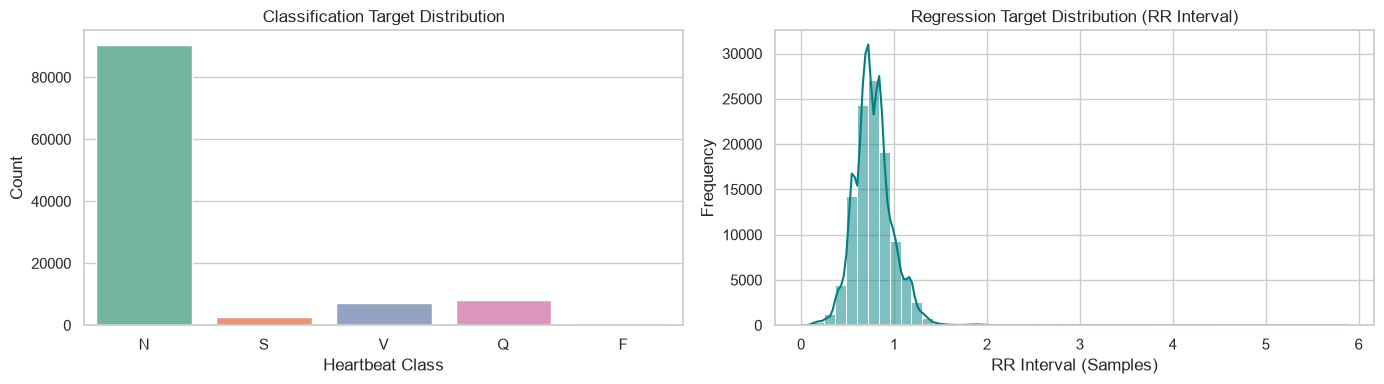

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Classification Target
sns.countplot(data=df_eda, x='target_classification_class', palette='Set2', ax=axes[0])
axes[0].set_title('Classification Target Distribution')
axes[0].set_xlabel('Heartbeat Class')
axes[0].set_ylabel('Count')
# Regression Target
sns.histplot(df_eda['target_regression_rr'], kde=True, color='teal', bins=50, ax=axes[1])
axes[1].set_title('Regression Target Distribution (RR Interval)')
axes[1].set_xlabel('RR Interval (Samples)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Insight — Target Distributions

The classification target is highly imbalanced, with the Normal (N) class containing the majority of the observations. The Ventricular (V) and Q classes have substantially fewer samples, while the Supraventricular (S) and Fusion (F) classes are also minority classes. This indicates that the dataset contains considerably more normal beats than abnormal beat categories.

The RR-interval distribution is concentrated mainly between approximately 0.5 and 1.2 samples, with a peak around the central region. Most observations therefore have RR intervals within this range, while only a small number of observations occur at larger RR intervals. The distribution is right-skewed, indicating the presence of relatively large RR-interval values.

The strong class imbalance will need to be considered when evaluating the classification models, particularly for minority classes.

### 2. Distribution Plots for Each Feature

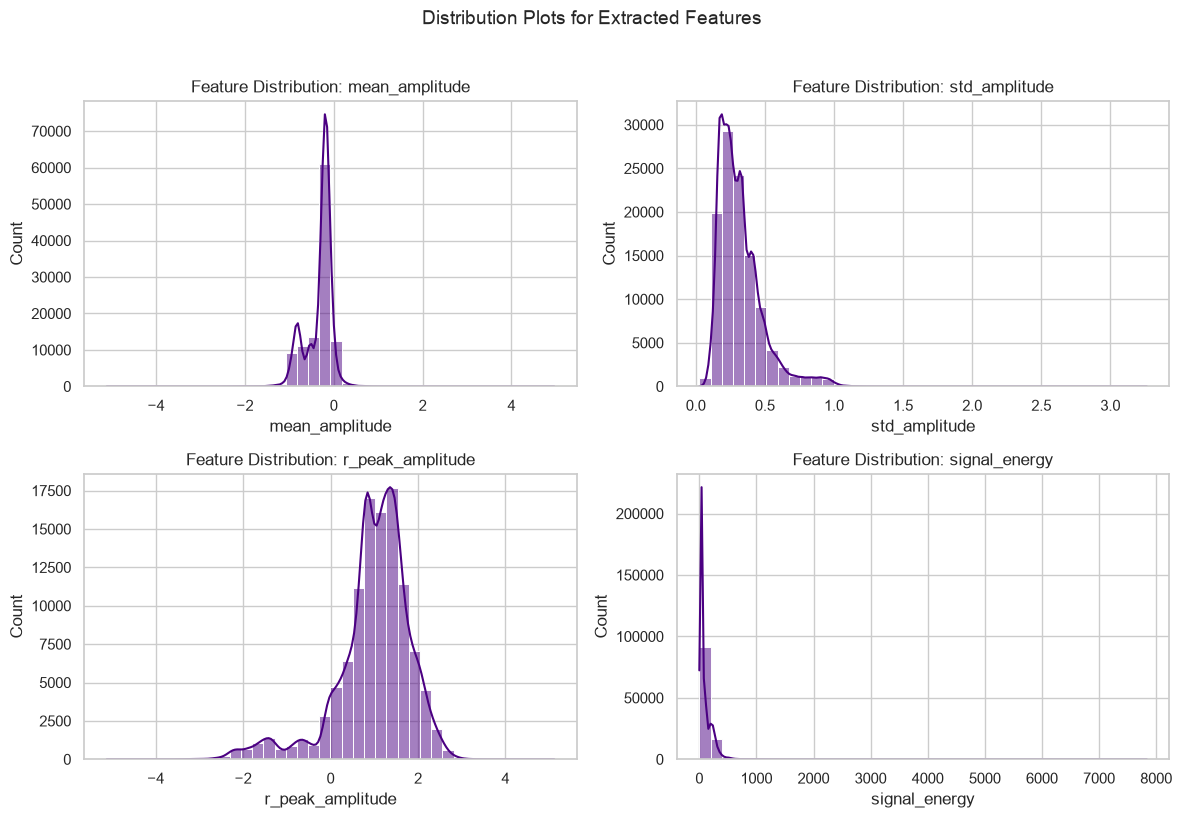

In [11]:
feature_cols = ['mean_amplitude', 'std_amplitude', 'r_peak_amplitude', 'signal_energy']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, col in enumerate(feature_cols):
    sns.histplot(df_eda[col], kde=True, ax=axes[idx], color='indigo', bins=40)
    axes[idx].set_title(f'Feature Distribution: {col}')
plt.suptitle('Distribution Plots for Extracted Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Insight — Extracted Feature Distributions

The extracted ECG features show noticeably different distributions.

The mean_amplitude feature is strongly concentrated around values close to zero, with relatively few observations occurring at more extreme positive or negative values. This indicates that the average amplitude of most ECG segments is relatively close to the central level.

The std_amplitude feature is right-skewed, with most observations concentrated at lower values and a decreasing frequency of larger standard-deviation values. This suggests that most ECG segments have relatively similar amplitude variability, while a smaller number exhibit substantially higher variability.

The r_peak_amplitude distribution is mainly concentrated in the positive range but also contains observations at lower and negative values. Its distribution is broader than that of mean_amplitude, indicating greater variation in the amplitude around the selected R-peak position.

The signal_energy feature is strongly right-skewed. Most observations have relatively low signal energy, while a small number of observations have considerably larger energy values. These extreme values may contribute to the statistical outliers identified during the data-cleaning stage.

Overall, the features have different scales and distributions, indicating that feature scaling will be important for algorithms that are sensitive to feature magnitude.

### 3. Correlation Heatmap

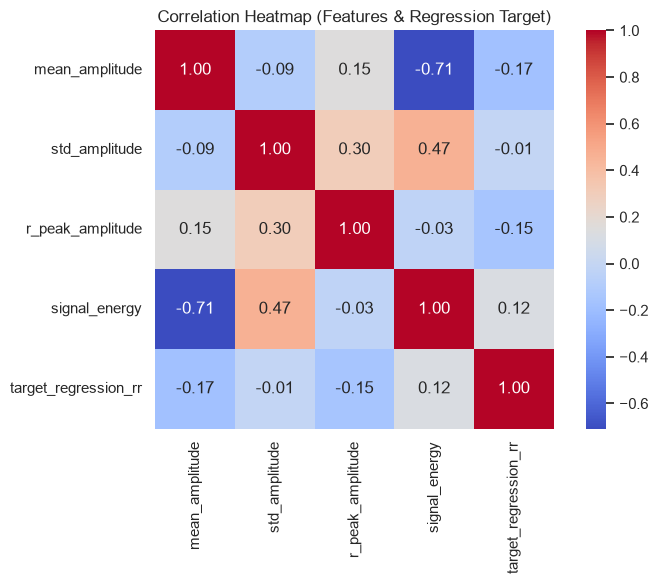

In [12]:
plt.figure(figsize=(8, 6))
corr_cols = feature_cols + ['target_regression_rr']
sns.heatmap(df_eda[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Heatmap (Features & Regression Target)')
plt.tight_layout()
plt.show()

Insight — Correlation Heatmap

The correlation heatmap shows that mean_amplitude has a strong negative correlation with signal_energy (−0.71). This indicates a substantial inverse linear relationship between these two extracted features.

std_amplitude has a moderate positive correlation with signal_energy (0.47), suggesting that ECG segments with greater amplitude variability tend to have higher signal energy.

The correlation between std_amplitude and r_peak_amplitude is relatively weak to moderate (0.30), while mean_amplitude and r_peak_amplitude have a weak positive correlation (0.15).

With respect to the regression target, target_regression_rr, the correlations are relatively weak: mean_amplitude (−0.17), r_peak_amplitude (−0.15), signal_energy (0.12), and std_amplitude (−0.01). This suggests that none of the individual extracted features has a strong linear relationship with the RR interval on its own.

Therefore, the relatively weak feature-target correlations indicate that non-linear models or combinations of multiple features may be useful for predicting the regression target.

### 4. Scatter Plots (Feature-Target Relationships)

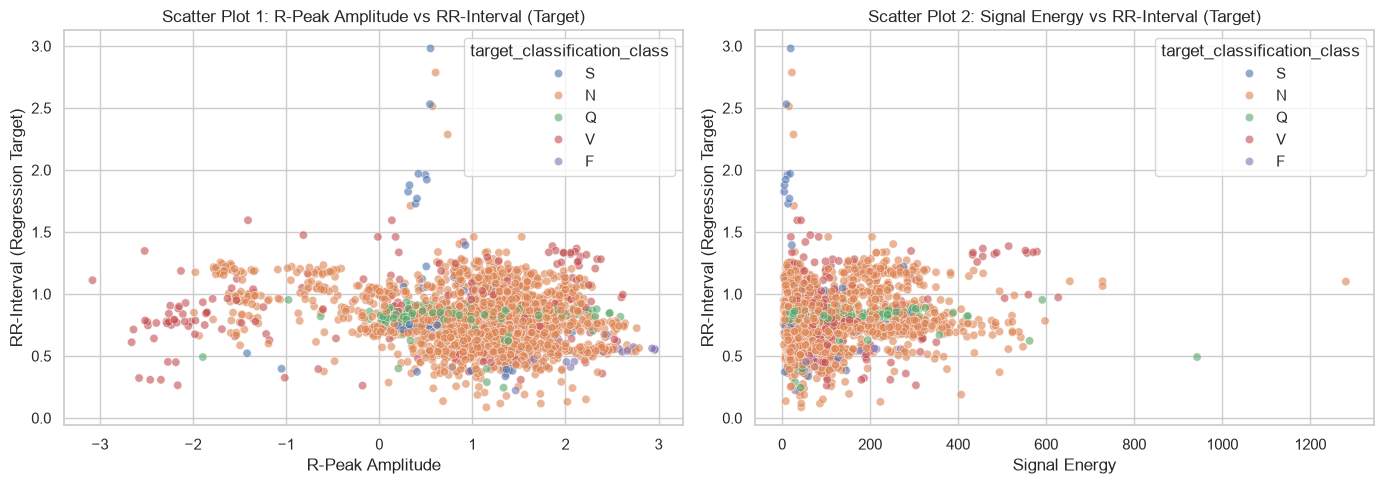

In [13]:
# Subsample 3,000 points so scatter plot stays fast and clear
sample_df = df_eda.sample(min(3000, len(df_eda)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Scatter Plot 1: R-peak Amplitude vs Regression Target
sns.scatterplot(
    data=sample_df, 
    x='r_peak_amplitude', 
    y='target_regression_rr', 
    hue='target_classification_class', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('Scatter Plot 1: R-Peak Amplitude vs RR-Interval (Target)')
axes[0].set_xlabel('R-Peak Amplitude')
axes[0].set_ylabel('RR-Interval (Regression Target)')
# Scatter Plot 2: Signal Energy vs Regression Target
sns.scatterplot(
    data=sample_df, 
    x='signal_energy', 
    y='target_regression_rr', 
    hue='target_classification_class', 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Scatter Plot 2: Signal Energy vs RR-Interval (Target)')
axes[1].set_xlabel('Signal Energy')
axes[1].set_ylabel('RR-Interval (Regression Target)')
plt.tight_layout()
plt.show()

Insight — Feature–Target Relationships

The R-peak amplitude versus RR-interval scatter plot shows a broad spread of observations rather than a clear linear trend. Most observations are concentrated within a relatively narrow RR-interval range, while a smaller number of observations occur at higher or lower RR intervals. The different heartbeat classes also overlap considerably, indicating that R-peak amplitude alone does not clearly separate the classes or strongly predict the RR interval.

The signal energy versus RR-interval plot similarly shows considerable dispersion. Most observations have lower signal-energy values and are concentrated around moderate RR intervals, while a smaller number of observations have much higher signal energy. There is no strong visual linear trend between signal energy and RR interval, which is consistent with the relatively weak correlation of 0.12 observed in the heatmap.

Overall, the scatter plots suggest that predicting RR interval from a single ECG feature may be difficult. Combining multiple waveform features and using models capable of capturing non-linear relationships may provide better predictive performance.

In [ ]:
#B1 — Data Cleaning
#The extracted ECG features are checked for missing values, duplicate observations and outliers. 
#The cleaning process is performed on the tabular feature representation created from the ECG signals.


#Creating a separate copy for data cleaning
df_clean = df_eda.copy()
print("Original dataset shape:", df_clean.shape)
df_clean.head()

In [ ]:
'''Missing values were first identified in all columns of the extracted ECG feature dataset.
If missing were present, the corresponding observations were removed because the datasetconsists of derived
numerical ECG measurements and target values. If Infinite values were present, the corresponding observations were
converted to missing values(Nan) and subsequently handled using the same missing-value strategy.
If no missing values were detected, no imputation was performed.'''


#Checking missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

total_missing = df_clean.isnull().sum().sum()
print("\nTotal missing values:", total_missing)

# Replace infinite values with NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# Remove rows containing missing values
if df_clean.isnull().sum().sum() > 0:
    df_clean = df_clean.dropna().reset_index(drop=True)
    print("\nRows containing missing/non-finite values were removed.")
else:
    print("\nNo missing or non-finite values found.")

In [ ]:
#Duplicate Check

'''
The dataset was checked for exact duplicate rows using all available feature and target columns.
Exact duplicates were removed because repeated identical observations may lead to biased evaluation results.
Only exact duplicate observations were considered duplicates. Similar but non-identical ECG observations were
retained because they may represent legitimate variations in ECG morphology.
'''


duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

In [ ]:
#Outliers detection

'''
Outliers in the numerical ECG features were identified using the Interquartile Range (IQR) method.
For each feature, the first quartile (Q1) and third quartile (Q3) were calculated. The IQR was obtained as the 
difference between Q3 and Q1. Observations below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR were considered statistical
outliers.
'''

feature_cols = ['mean_amplitude','std_amplitude','r_peak_amplitude','signal_energy']

outlier_summary = []

for col in feature_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower_bound) |(df_clean[col] > upper_bound))

    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outliers.sum(),
        'Outlier Percentage': round(
            100 * outliers.mean(), 2
        )
    })

outlier_df = pd.DataFrame(outlier_summary)

print("\nOutlier Summary:")
display(outlier_df)

In [ ]:
#Visulaizing Outliers
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean[feature_cols])

plt.title("Boxplots for Outlier Detection in ECG Features")
plt.xlabel("ECG Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
#Outlier Treatement

'''
The detected outliers were treated using IQR-based capping rather than removing the corresponding observations.
This approach was selected because extreme values in ECG-derived features may represent genuine variations in
heartbeat morphology, particularly in abnormal cardiac beats. Removing all statistical outliers could therefore 
discard potentially meaningful observations required for the classification and clustering tasks.

With IQR-based capping, values outside the lower and upper IQR boundaries are limited to the corresponding boundary 
values while the observations themselves are retained.

This reduces the influence of extreme feature values on machine learning models while preserving the original 
number of ECG observations as much as possible.
'''

for col in feature_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

In [ ]:
print("\nFinal dataset shape:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

print("\nFinal dataset preview:")
display(df_clean.head())